In [1]:
# imports
# Add cle_fun to PYTHON_PATH
import sys, os, json
sys.path.append("../../clonscal")


from analytic.formulas import *

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

os.environ["SCAL_TYPE"] = "complex"
os.environ["PRECISION"] = "single"
os.environ["MY_NUMBA_TARGET"] = "numba"

from simulation.config import Config
from simulation.cl_simulation import ComplexLangevinSimulation
from simulation.gpu_handler import GPU_handler

from src.obs_kernels import (
    n_moment_kernel, 
    dse_n_moment_kernel,
    abs_drift
)

import src.scal as scal
from src.numba_target import (
    use_cuda,
    my_act_parallel_loop
)
from src.utils import (
    update_histogram_complex, 
    update_histogram_real,
    calculate_stats_complex,
    gaussian_modified_density_drift_kernel
)

if use_cuda: from numba import cuda


Using single precision
Using C^1
Using Numba


## Testing sub routines

#### testing noise kernel

In [2]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    # Function to profile
    def get_args():
        sim.cldyn_kernel_bridge.get_current_params()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()

    def update_noise_get():
        sim.update_noise(*sim.cldyn_kernel_args[sim.noise_kernel].values())

    def update_noise():
        sim.update_noise(*sim.cldyn_kernel_args[sim.noise_kernel].values())

    def update_drift(): 
        sim.update_drift(*sim.cldyn_kernel_args[sim.drift_kernel].values())

    def update_field():
        sim.update_field(*sim.cldyn_kernel_args[sim.evolve_kernel].values())

    def swap():
        sim.swap()
        
    def set_apative_stepsize():
        sim.set_apative_stepsize()
    
    def step():
        sim.step()

    functions_to_test = [get_args, update_noise, update_drift, update_field, set_apative_stepsize, swap, step]
    # warmup
    for func in functions_to_test:
        func()

    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


  0%|          | 0/7 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:26<00:00,  3.85s/it]


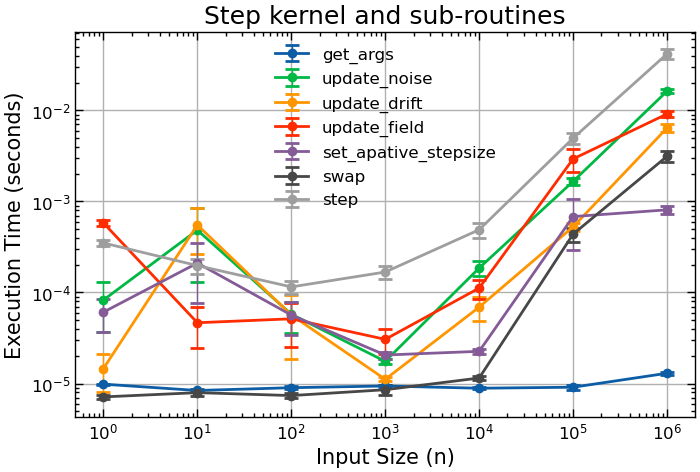

In [3]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

check with magic cell

In [ ]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    sim.register_observable('3_moment', obs_kernel=n_moment_kernel, const_param={"order" : 3},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()
    
    def kill():
        sim.kill_trajs()

    def mark_eq():
        sim.trackers["1_moment"].mark_equilibrated_trajs()
        sim.trackers["2_moment"].mark_equilibrated_trajs()
        sim.trackers["3_moment"].mark_equilibrated_trajs()

    def compute1():
        sim.trackers["1_moment"].compute()

    def compute2():
        sim.trackers["2_moment"].compute()

    def compute3():
        sim.trackers["3_moment"].compute()


    functions_to_test = [kill, mark_eq, compute1, compute2]
    
    for func in functions_to_test: 
        func()
    
    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


100%|██████████| 7/7 [00:12<00:00,  1.81s/it]


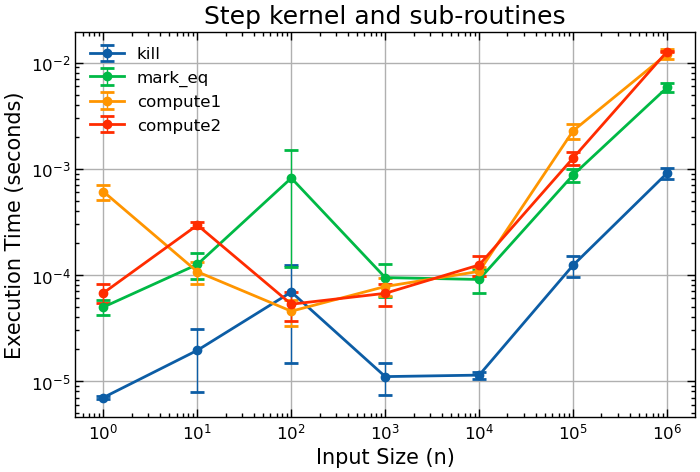

In [5]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

In [6]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=False, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()
    
    def full_step():
        sim.step()
        sim.kill_trajs()
        for _, tr in sim.trackers.items():
            tr.mark_equilibrated_trajs()
            tr.compute()


    functions_to_test = [full_step]
    
    for func in functions_to_test: 
        func()
    
    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 


100%|██████████| 7/7 [00:16<00:00,  2.42s/it]


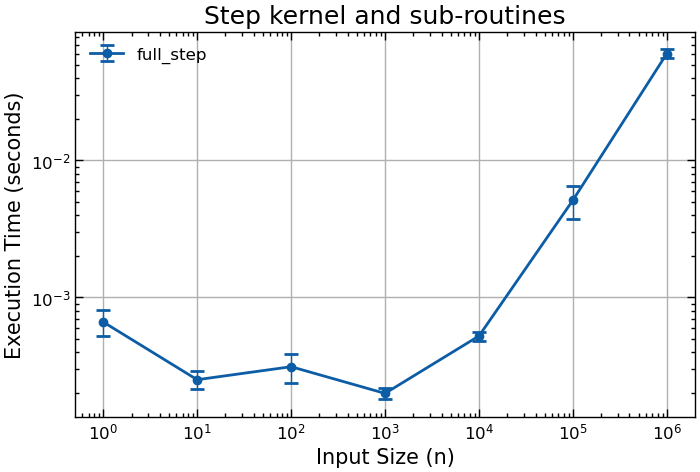

In [8]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

In [21]:
import timeit
import tqdm
import numpy as np
import scienceplots
import matplotlib.pyplot as plt

benchmark = {}

num_repeats = 5  # Number of repetitions for statistics
num_executions = 50  # Number of executions in each timeit call
num_trajs_max_exp = 6

# Trajectories range from 1 to 10^5
trajs_num = np.logspace(0, num_trajs_max_exp, num_trajs_max_exp + 1)

# Define a function for benchmarking
for trajs in tqdm.tqdm(trajs_num):
    config = Config(trajs=int(trajs))
    sim = ComplexLangevinSimulation(config)
    sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=0.00, maximal_lt=100)
    if use_cuda:
        gpu_handler = GPU_handler(sim)
        gpu_handler.to_device()

    sim.cldyn_kernel_args = sim.cldyn_kernel_bridge.get_current_params()
    
    def kill():
        sim.kill_trajs()

    def mark_eq():
        sim.trackers["1_moment"].mark_equilibrated_trajs()

    def compute1():
        sim.trackers["1_moment"].compute()



    functions_to_test = [kill, mark_eq, compute1]
    
    for func in functions_to_test: 
        func()
    
    for func in functions_to_test:
        if func.__name__ not in benchmark.keys():
            benchmark[func.__name__] = {"times": [], "errors": []}

        # Run timeit.repeat to get an array of timings
        results = timeit.repeat(func, globals=globals(), number=num_executions, repeat=num_repeats)

        average_times = np.array(results)/num_executions
        mean_time = np.mean(average_times)
        std_dev = np.std(average_times)
        sem = std_dev / np.sqrt(len(average_times))

        benchmark[func.__name__]["times"].append(mean_time)
        benchmark[func.__name__]["errors"].append(sem) 



100%|██████████| 7/7 [00:06<00:00,  1.12it/s]


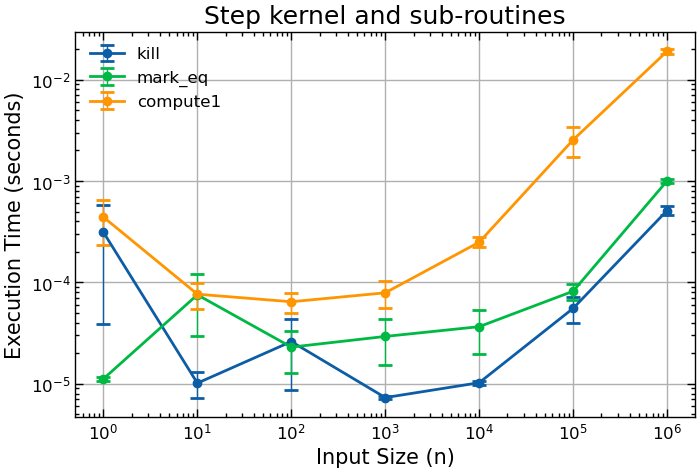

In [24]:
plt.style.use(['science', "notebook"])

plt.rcParams.update({
    'font.size': 20,  # Main font size
    'axes.labelsize': 15,  # Axis labels
    'axes.titlesize': 18,  # Title size
    'legend.fontsize': 12,  # Legend font
    'xtick.labelsize': 12,  # Tick labels
    'ytick.labelsize': 12,
})

# Plot results with error bars
plt.figure(figsize=(8, 5))

for key, value in benchmark.items():
    plt.errorbar(trajs_num, value["times"], yerr=value["errors"], fmt='o-', capsize=5, capthick=2, elinewidth=1, label=key)
plt.xlabel("Input Size (n)")
plt.ylabel("Execution Time (seconds)")
plt.title("Step kernel and sub-routines")

plt.grid(True)
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.show()

# Single Traj study for autocorr

In [11]:
import tqdm
config = Config(trajs=int(1e0), steps = int(1e5), dt = 1e-4, history_grid_size=1e-3)
sim = ComplexLangevinSimulation(config)
sim.register_observable('1_moment', obs_kernel=n_moment_kernel, const_param={"order" : 1},  langevin_history=True, thermal_time=0, auto_corr=sim.dt/10, maximal_lt=100)
# sim.register_observable('2_moment', obs_kernel=n_moment_kernel, const_param={"order" : 2},  langevin_history=True, thermal_time=0, auto_corr=sim.dt, maximal_lt=100)
if use_cuda:
    gpu_handler = GPU_handler(sim)
    gpu_handler.to_device()

for idx in tqdm.tqdm(range(config.steps)):
    sim.step()
    sim.kill_trajs()
    for _, tr in sim.trackers.items():
        tr.mark_equilibrated_trajs()
        tr.compute()
sim.finish()

100%|██████████| 100000/100000 [00:37<00:00, 2688.37it/s]


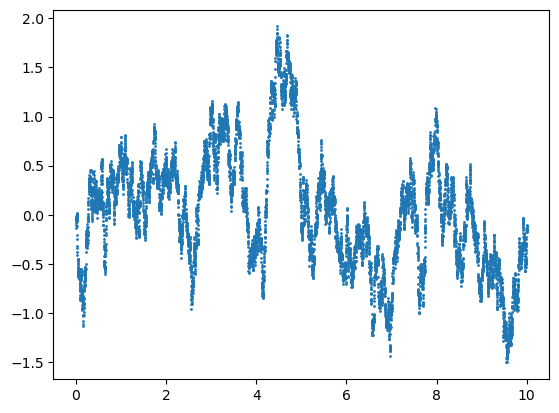

In [12]:
plt.scatter(sim.trackers["1_moment"].history_meas_times, sim.trackers["1_moment"].history_result, s = 1)